  0%|          | 0/1000 [00:00<?, ?it/s]

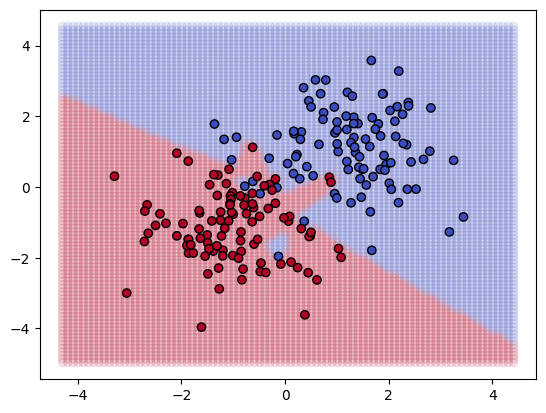

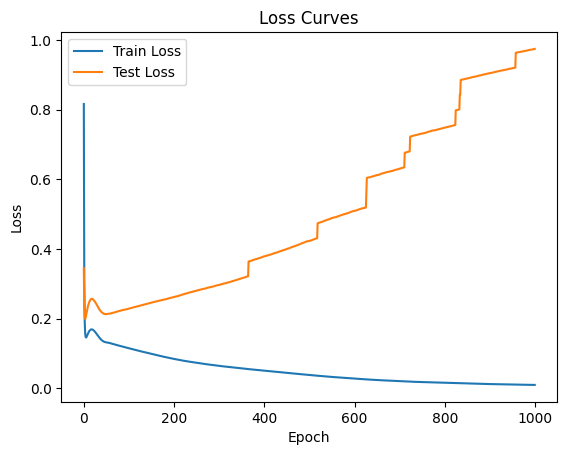

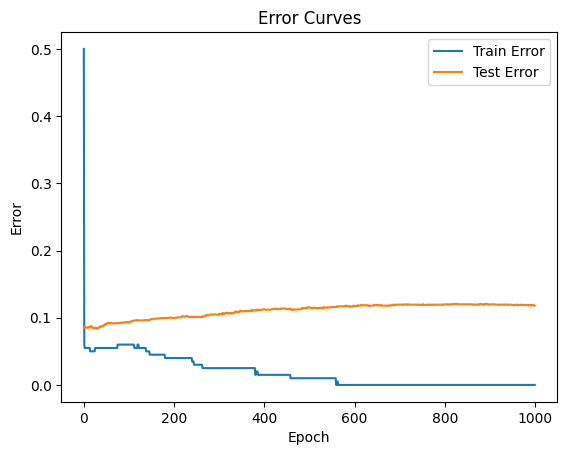

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate 2D Gaussian data for 2 classes
def generate_data(n_train=100, n_test=1000, mean1=[1, 1], mean2=[-1, -1], cov=[[1, 0], [0, 1]]):
    class1_train = np.random.multivariate_normal(mean1, cov, n_train)
    class2_train = np.random.multivariate_normal(mean2, cov, n_train)
    class1_test = np.random.multivariate_normal(mean1, cov, n_test)
    class2_test = np.random.multivariate_normal(mean2, cov, n_test)
    
    train_data = np.vstack((class1_train, class2_train))
    train_labels = np.hstack((np.zeros(n_train), np.ones(n_train)))
    
    test_data = np.vstack((class1_test, class2_test))
    test_labels = np.hstack((np.zeros(n_test), np.ones(n_test)))
    
    return train_data, train_labels, test_data, test_labels

# Define a 2-layer MLP
class MLP(nn.Module):
    def __init__(self, hidden_dim=1000):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(2, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        return x

# Plot decision boundary
def plot_decision_boundary(model, train_data, train_labels):
    x_min, x_max = train_data[:, 0].min() - 1, train_data[:, 0].max() + 1
    y_min, y_max = train_data[:, 1].min() - 1, train_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    with torch.no_grad():
        preds = model(grid_tensor).reshape(xx.shape).numpy()
    preds = preds > 0.5
    plt.scatter(grid[:, 0], grid[:, 1], c=preds, alpha=0.1, cmap='coolwarm')
    plt.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, edgecolors='k', marker='o', cmap='coolwarm')
    plt.show()

# Generate data
train_data, train_labels, test_data, test_labels = generate_data()
data_train_tensor = torch.tensor(train_data, dtype=torch.float32)
labels_train_tensor = torch.tensor(train_labels, dtype=torch.float32).view(-1, 1)
data_test_tensor = torch.tensor(test_data, dtype=torch.float32)
labels_test_tensor = torch.tensor(test_labels, dtype=torch.float32).view(-1, 1)

# Define model, loss function, and optimizer
model = MLP()
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005)

# Track losses and errors
train_losses = []
test_losses = []
train_errors = []
test_errors = []

# Train the model
num_epochs = 1000
for epoch in tqdm(range(num_epochs)):
    model.train()
    optimizer.zero_grad()
    outputs = model(data_train_tensor)
    loss = criterion(outputs, labels_train_tensor)
    loss.backward()
    optimizer.step()

    # Track training loss and error
    train_losses.append(loss.item())
    train_preds = (outputs.detach().numpy() > 0.5).astype(int)
    train_error = 1 - accuracy_score(train_labels, train_preds)
    train_errors.append(train_error)

    # Track test loss and error
    model.eval()
    with torch.no_grad():
        test_outputs = model(data_test_tensor)
        test_loss = criterion(test_outputs, labels_test_tensor)
        test_losses.append(test_loss.item())
        test_preds = (test_outputs.numpy() > 0.5).astype(int)
        test_error = 1 - accuracy_score(test_labels, test_preds)
        test_errors.append(test_error)

# Plot the decision boundary
plot_decision_boundary(model, train_data, train_labels)

# Plot the training and test loss curves
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()

# Plot the training and test error curves
plt.figure()
plt.plot(train_errors, label='Train Error')
plt.plot(test_errors, label='Test Error')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.title('Error Curves')
plt.show()
